# Python integration

Python is a rapidly glowing ecosystem for data analysis and visualization in seismology. Followings are some tips & tricks for those who would like to handle the input/output of the OpenSWPC in python. The following example uses

ObsPy
numpy
xarray
PyGMT
under the Jupyter Notebook environment.

Input parameter files¶
A python module OpenSWPC/src/tools/swpc.py contains several utility functions to handle input parameter to the OpenSWPC. To use it, first add this directory to the module path

```python
import sys
sys.path.append('/path/to/OpenSWPC/src/tools/')
```

Then, the module can be loaded as follows: 

In [1]:
import swpc

A function `prm_new()` create the default parameter set. These parameters are equivalent to that defined in `example/input.inf`.

In [2]:
prm0 = swpc.prm_new()

Parameter data are stored in a simple dictionary as shown below. 

In [3]:
print(prm0)

{'title': 'swpc', 'odir': './out', 'ntdec_r': 50, 'strict_mode': False, 'nproc_x': 2, 'nproc_y': 2, 'nx': 384, 'ny': 384, 'nz': 384, 'nt': 1000, 'dx': 0.5, 'dy': 0.5, 'dz': 0.5, 'dt': 0.02, 'vcut': 1.5, 'xbeg': -96.0, 'ybeg': -96.0, 'zbeg': -10.0, 'tbeg': 0.0, 'clon': 139.7604, 'clat': 35.7182, 'phi': 0.0, 'fq_min': 0.02, 'fq_max': 2.0, 'fq_ref': 1.0, 'snp_format': 'netcdf', 'xy_ps%sw': False, 'xz_ps%sw': True, 'yz_ps%sw': False, 'fs_ps%sw': False, 'ob_ps%sw': True, 'xy_v%sw': False, 'xz_v%sw': True, 'yz_v%sw': False, 'fs_v%sw': False, 'ob_v%sw': True, 'xy_u%sw': False, 'xz_u%sw': True, 'yz_u%sw': False, 'fs_u%sw': False, 'ob_u%sw': True, 'z0_xy': 7.0, 'x0_yz': 0.0, 'y0_xz': 0.0, 'ntdec_s': 5, 'idec': 2, 'jdec': 2, 'kdec': 2, 'sw_wav_v': True, 'sw_wav_u': False, 'sw_wav_stress': False, 'sw_wav_strain': False, 'ntdec_w': 5, 'ntdec_w_prg': 0, 'st_format': 'xy', 'fn_stloc': './example/stloc.xy', 'wav_format': 'sac', 'stf_format': 'xym0ij', 'stftype': 'kupper', 'fn_stf': './example/source.

A function `prm_print(prm)` would be better for looking parameters: 

In [4]:
swpc.prm_print(prm0)

title              =   'swpc'
odir               =   './out'
ntdec_r            =   50
strict_mode        =   .false.
nproc_x            =   2
nproc_y            =   2
nx                 =   384
ny                 =   384
nz                 =   384
nt                 =   1000
dx                 =   0.5
dy                 =   0.5
dz                 =   0.5
dt                 =   0.02
vcut               =   1.5
xbeg               =   -96.0
ybeg               =   -96.0
zbeg               =   -10.0
tbeg               =   0.0
clon               =   139.7604
clat               =   35.7182
phi                =   0.0
fq_min             =   0.02
fq_max             =   2.0
fq_ref             =   1.0
snp_format         =   'netcdf'
xy_ps%sw           =   .false.
xz_ps%sw           =   .true.
yz_ps%sw           =   .false.
fs_ps%sw           =   .false.
ob_ps%sw           =   .true.
xy_v%sw            =   .false.
xz_v%sw            =   .true.
yz_v%sw            =   .false.
fs_v%sw            =   .

Also, one can read the parameter file by using `prm_read()` function rather than creating new one. For example, 

```python
prm1 = swpc.prm_read('/path/to/OpenSWPC/example/input.inf')
```
As this is a simple dictionary, the user can easily change the parameter values if necessary. 
```python
prm1['title'] = 'new-simulation'
prm1['nx'] = 1024
prm1['ny'] = 1024
prm1['nz'] = 1024
```

To save the parameter to use in OpenSWPC, use `prm_save()` function. 

```python
swpc.prm_save(prm, 'new.inf')
```

## Model viewer

functions `swpc.chkregion_2d()` and `swpc.chkregion_3d()` enables us to confirm the model size and coordinate settings visually. Here is an example: 

In [5]:
prm2 = swpc.prm_new()

prm2['nx'] = 1024
prm2['ny'] = 768
prm2['nz'] = 512
prm2['nproc_x'] = 16
prm2['nproc_y'] = 8
prm2['phi'] = 35

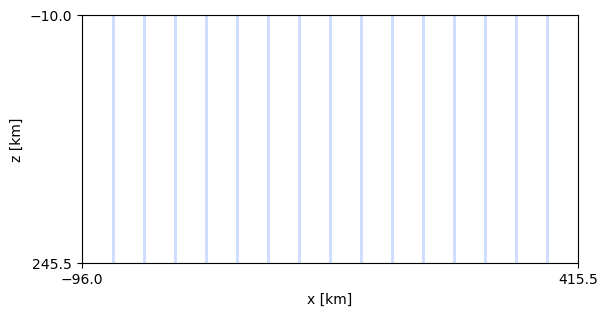

In [7]:
swpc.chkregion_2d(prm2);

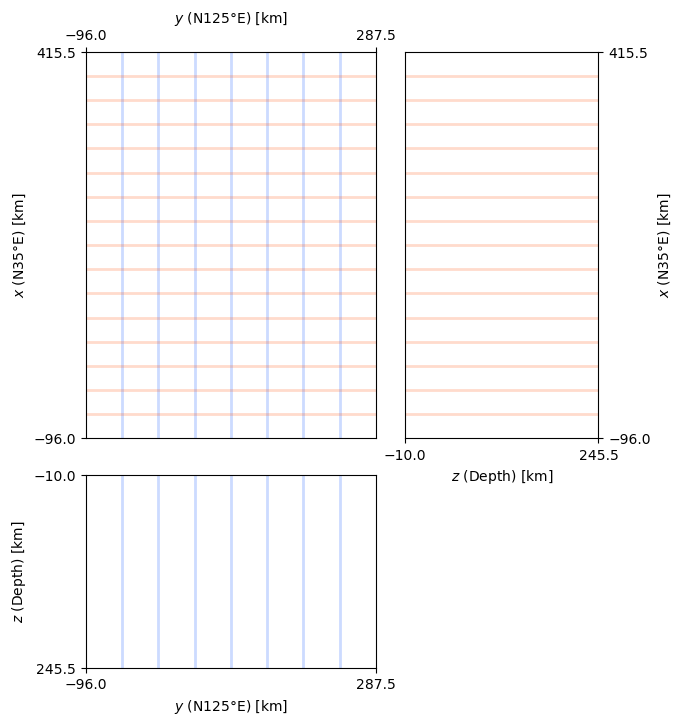

In [8]:
swpc.chkregion_3d(prm2);